# SpaceX Falcon 9 First Stage Landing Prediction
## 2. Exploratory Data Analysis & SQL Analysis

This notebook covers:
- Loading cleaned dataset
- SQL queries on launch data
- Statistical EDA
- Feature analysis

## Import Libraries and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('✅ Libraries imported')

✅ Libraries imported


In [2]:
# Load the cleaned dataset
try:
    df = pd.read_csv('dataset_part_1_cleaned.csv')
    print(f'✅ Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns')
except FileNotFoundError:
    print('⚠️ Using sample data for demonstration')
    # Create sample data if file not found
    df = pd.DataFrame({
        'FlightNumber': range(1, 91),
        'PayloadMass': np.random.uniform(500, 15000, 90),
        'Orbit': ['LEO', 'GEO', 'ISS', 'HEO', 'VLEO'] * 18,
        'LaunchSite': ['CCAFS LC-40', 'KSC LC-39A', 'VAFB SLC-4E'] * 30,
        'Class': np.random.choice([0, 1], 90, p=[0.3, 0.7])
    })
    print(f'Sample dataset created: {df.shape}')

✅ Dataset loaded: 187 rows, 16 columns


## SQL Analysis

In [3]:
# Create SQLite database from DataFrame
conn = sqlite3.connect('spacex.db')
df.to_sql('launches', conn, if_exists='replace', index=False)

print('✅ SQLite database created')
print(f'\nDatabase tables:')

# Get table info
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
for table in tables:
    print(f'  - {table[0]}')

✅ SQLite database created

Database tables:
  - launches


In [4]:
# SQL Query 1: Unique Launch Sites
query1 = "SELECT DISTINCT LaunchSite FROM launches ORDER BY LaunchSite"
result1 = pd.read_sql_query(query1, conn)
print('Query 1: Unique Launch Sites')
print(result1)
print()

Query 1: Unique Launch Sites
        LaunchSite
0     CCSFS SLC 40
1       KSC LC 39A
2  Kwajalein Atoll
3      VAFB SLC 4E



In [5]:
# SQL Query 2: Count launches by orbit type
query2 = "SELECT Orbit, COUNT(*) as LaunchCount FROM launches GROUP BY Orbit ORDER BY LaunchCount DESC"
result2 = pd.read_sql_query(query2, conn)
print('Query 2: Launches by Orbit Type')
print(result2)
print()

Query 2: Launches by Orbit Type
    Orbit  LaunchCount
0    VLEO           58
1     GTO           35
2     ISS           33
3     LEO           20
4      PO           14
5     SSO           12
6     MEO            6
7     TLI            2
8     GEO            2
9      SO            1
10    HEO            1
11    HCO            1
12  ES-L1            1
13   None            1



In [6]:
# SQL Query 3: Success rate by launch site
query3 = """SELECT LaunchSite, 
           COUNT(*) as TotalLaunches,
           SUM(Class) as SuccessfulLandings,
           ROUND(100.0 * SUM(Class) / COUNT(*), 2) as SuccessRate
           FROM launches 
           GROUP BY LaunchSite 
           ORDER BY SuccessRate DESC"""
result3 = pd.read_sql_query(query3, conn)
print('Query 3: Success Rate by Launch Site')
print(result3)
print()

Query 3: Success Rate by Launch Site
        LaunchSite  TotalLaunches  SuccessfulLandings  SuccessRate
0       KSC LC 39A             55                  48        87.27
1      VAFB SLC 4E             28                  24        85.71
2     CCSFS SLC 40             99                  75        75.76
3  Kwajalein Atoll              5                   0         0.00



In [7]:
# SQL Query 4: Average payload mass by orbit
query4 = """SELECT Orbit, 
           COUNT(*) as Count,
           ROUND(AVG(PayloadMass), 2) as AvgPayloadMass,
           ROUND(MIN(PayloadMass), 2) as MinPayload,
           ROUND(MAX(PayloadMass), 2) as MaxPayload
           FROM launches 
           GROUP BY Orbit 
           ORDER BY AvgPayloadMass DESC"""
result4 = pd.read_sql_query(query4, conn)
print('Query 4: Payload Statistics by Orbit')
print(result4)
print()

Query 4: Payload Statistics by Orbit
    Orbit  Count  AvgPayloadMass  MinPayload  MaxPayload
0    VLEO     58        14352.76     13200.0     15600.0
1      PO     14         8293.79       500.0     15600.0
2      SO      1         6035.00      6035.0      6035.0
3    None      1         6035.00      6035.0      6035.0
4     GEO      2         4986.50      3938.0      6035.0
5     GTO     35         4887.94      1800.0      7076.0
6     LEO     20         4194.50        20.0     13260.0
7     ISS     33         4132.66       400.0     12519.0
8     SSO     12         3352.50       475.0      6035.0
9     MEO      6         3290.33       600.0      4400.0
10    HCO      1         1350.00      1350.0      1350.0
11    TLI      2          674.00       670.0       678.0
12  ES-L1      1          570.00       570.0       570.0
13    HEO      1          350.00       350.0       350.0



In [8]:
conn.close()
print('✅ SQL analysis complete')

✅ SQL analysis complete


## Statistical EDA

In [9]:
print('Dataset Overview:')
print(df.head(10))
print(f'\nDataset Shape: {df.shape}')
print(f'\nData Types:')
print(df.dtypes)
print(f'\nMissing Values:')
print(df.isnull().sum())

Dataset Overview:
  BoosterVersion  PayloadMass Orbit       LaunchSite    Outcome  Flights  \
0       Falcon 1         20.0   LEO  Kwajalein Atoll  None None        1   
1       Falcon 1       6035.0   LEO  Kwajalein Atoll  None None        1   
2       Falcon 1       6035.0   LEO  Kwajalein Atoll  None None        1   
3       Falcon 1        165.0   LEO  Kwajalein Atoll  None None        1   
4       Falcon 1        200.0   LEO  Kwajalein Atoll  None None        1   
5       Falcon 9       6035.0   LEO     CCSFS SLC 40  None None        1   
6       Falcon 9       6035.0   LEO     CCSFS SLC 40  None None        1   
7       Falcon 9        525.0   LEO     CCSFS SLC 40  None None        1   
8       Falcon 9        400.0   ISS     CCSFS SLC 40  None None        1   
9       Falcon 9        677.0   ISS     CCSFS SLC 40  None None        1   

   GridFins  Reused   Legs LandingPad  Block  ReusedCount    Serial  \
0     False   False  False        NaN    NaN            0  Merlin1A   
1  

In [10]:
print('Descriptive Statistics:')
print(df.describe())

Descriptive Statistics:
        PayloadMass     Flights       Block  ReusedCount   Longitude  \
count    187.000000  187.000000  182.000000   187.000000  187.000000   
mean    7623.270321    3.636364    4.148352     5.208556  -79.939916   
std     5250.594257    3.267034    1.416155     4.754662   43.571372   
min       20.000000    1.000000    1.000000     0.000000 -120.610829   
25%     3118.000000    1.000000    3.250000     1.000000  -80.603956   
50%     6035.000000    2.000000    5.000000     4.000000  -80.577366   
75%    13260.000000    5.000000    5.000000     9.000000  -80.577366   
max    15600.000000   14.000000    5.000000    13.000000  167.743129   

         Latitude       Class  
count  187.000000  187.000000  
mean    28.962590    0.786096  
std      3.952563    0.411161  
min      9.047721    0.000000  
25%     28.561857    1.000000  
50%     28.561857    1.000000  
75%     28.608058    1.000000  
max     34.632093    1.000000  



Landing Success Analysis:
Total Launches: 187
Successful Landings: 147
Failed Landings: 40
Success Rate: 78.61%


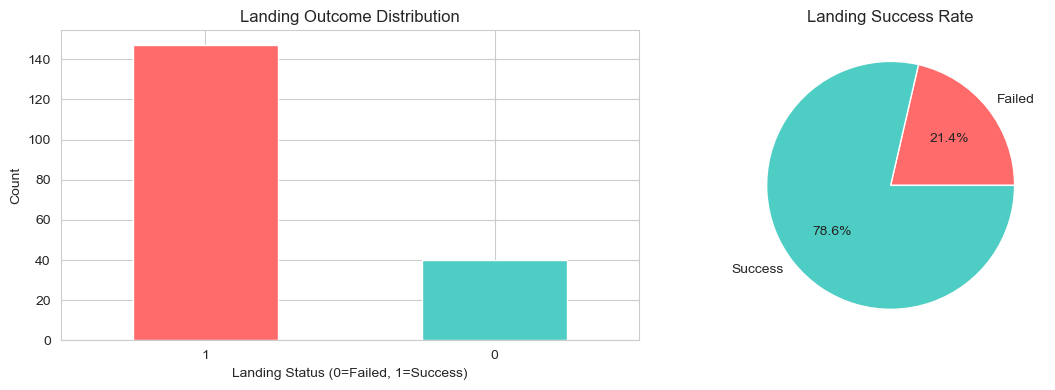

✅ Saved: landing_success_distribution.png


In [11]:
# Landing success analysis
if 'Class' in df.columns:
    success_rate = df['Class'].mean()
    print(f'\nLanding Success Analysis:')
    print(f'Total Launches: {len(df)}')
    print(f'Successful Landings: {(df["Class"] == 1).sum()}')
    print(f'Failed Landings: {(df["Class"] == 0).sum()}')
    print(f'Success Rate: {success_rate:.2%}')
    
    # Visualize success distribution
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Count plot
    df['Class'].value_counts().plot(kind='bar', ax=axes[0], color=['#FF6B6B', '#4ECDC4'])
    axes[0].set_title('Landing Outcome Distribution')
    axes[0].set_xlabel('Landing Status (0=Failed, 1=Success)')
    axes[0].set_ylabel('Count')
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
    
    # Pie chart
    sizes = [df['Class'].value_counts().get(0, 0), df['Class'].value_counts().get(1, 0)]
    labels = ['Failed', 'Success']
    axes[1].pie(sizes, labels=labels, autopct='%1.1f%%', colors=['#FF6B6B', '#4ECDC4'])
    axes[1].set_title('Landing Success Rate')
    
    plt.tight_layout()
    plt.savefig('landing_success_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('✅ Saved: landing_success_distribution.png')

## Feature Analysis

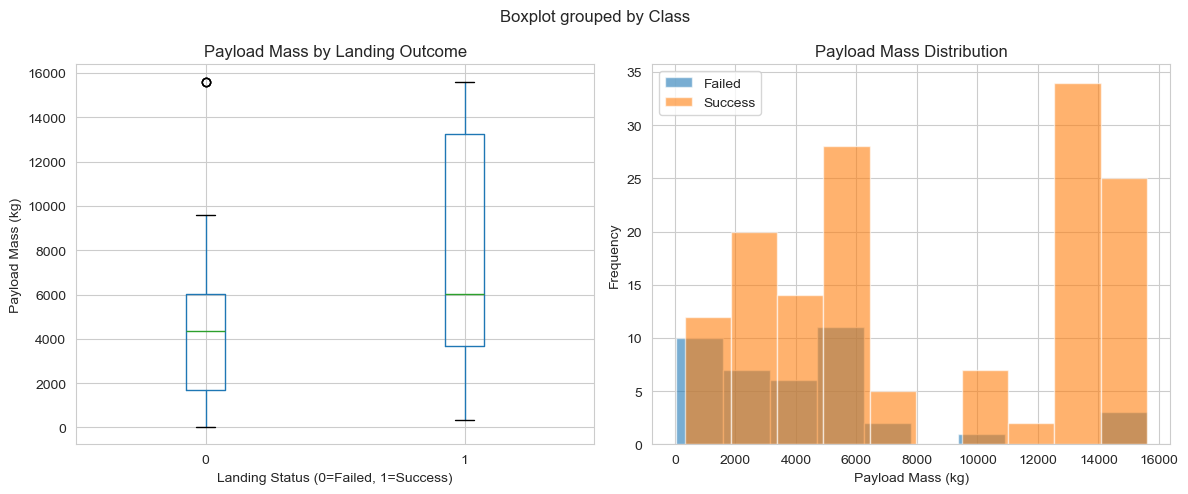

✅ Saved: payload_analysis.png


In [12]:
# Payload mass analysis by outcome
if 'PayloadMass' in df.columns and 'Class' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Distribution
    df.boxplot(column='PayloadMass', by='Class', ax=axes[0])
    axes[0].set_title('Payload Mass by Landing Outcome')
    axes[0].set_xlabel('Landing Status (0=Failed, 1=Success)')
    axes[0].set_ylabel('Payload Mass (kg)')
    
    # Histogram
    for class_val in [0, 1]:
        label = 'Success' if class_val == 1 else 'Failed'
        axes[1].hist(df[df['Class'] == class_val]['PayloadMass'], alpha=0.6, label=label)
    axes[1].set_title('Payload Mass Distribution')
    axes[1].set_xlabel('Payload Mass (kg)')
    axes[1].set_ylabel('Frequency')
    axes[1].legend()
    
    plt.tight_layout()
    plt.savefig('payload_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('✅ Saved: payload_analysis.png')

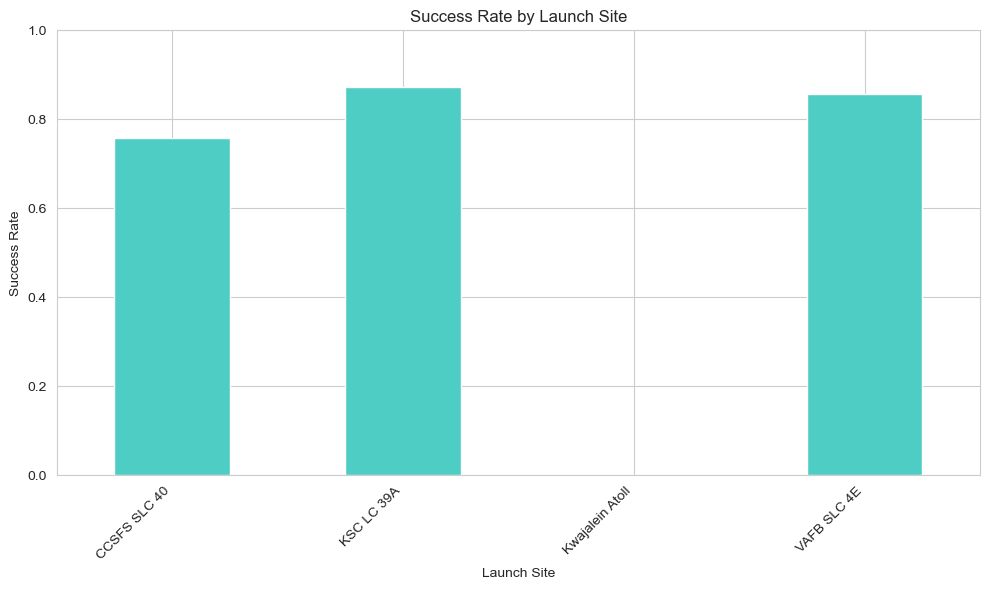

✅ Saved: site_success_rates.png


In [13]:
# Launch site success rates
if 'LaunchSite' in df.columns and 'Class' in df.columns:
    success_by_site = df.groupby('LaunchSite')['Class'].agg(['sum', 'count'])
    success_by_site['success_rate'] = success_by_site['sum'] / success_by_site['count']
    
    fig, ax = plt.subplots(figsize=(10, 6))
    success_by_site['success_rate'].plot(kind='bar', ax=ax, color='#4ECDC4')
    ax.set_title('Success Rate by Launch Site')
    ax.set_xlabel('Launch Site')
    ax.set_ylabel('Success Rate')
    ax.set_ylim([0, 1])
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('site_success_rates.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('✅ Saved: site_success_rates.png')

## Summary Statistics

In [14]:
print('\n' + '='*60)
print('EDA SUMMARY REPORT')
print('='*60)
print(f'\nDataset Dimensions: {df.shape}')
print(f'Total Records: {len(df)}')
print(f'\nFeatures: {list(df.columns)}')
print(f'\nData Quality:')
print(f'  - Complete Records: {df.dropna().shape[0]}')
print(f'  - Missing Values: {df.isnull().sum().sum()}')
print(f'\n✅ EDA Analysis Complete')


EDA SUMMARY REPORT

Dataset Dimensions: (187, 16)
Total Records: 187

Features: ['BoosterVersion', 'PayloadMass', 'Orbit', 'LaunchSite', 'Outcome', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial', 'Longitude', 'Latitude', 'Class']

Data Quality:
  - Complete Records: 150
  - Missing Values: 42

✅ EDA Analysis Complete
